In [1]:
# ============================================================
# Task 3: Energy Consumption Forecasting (next 24h per building)
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

telemetry_df = pd.read_csv("sensor_telemetry.csv", parse_dates=["timestamp"])
telemetry_df = telemetry_df.dropna(subset=["power_consumption"])
print(telemetry_df.shape)

(175012, 12)


In [2]:
#  Aggregate to building-level hourly consumption
# ASSUMPTION: "energy consumption for the building" = sum of power_consumption across
# all assets in that building. Hourly resolution chosen since raw 5-min data is noisy
# and a 24h-ahead operational forecast doesn't need minute-level granularity.

building_hourly = (
    telemetry_df.set_index("timestamp")
    .groupby("building_id")
    .resample("1h")["power_consumption"]
    .sum()
    .reset_index()
    .rename(columns={"power_consumption": "total_power_kwh"})
)

print(building_hourly.shape)
building_hourly.head()

(1440, 3)


,building_id,timestamp,total_power_kwh
0,SITE-01-BLDG-01,2026-08-04 21:00:00,2293.681
1,SITE-01-BLDG-01,2026-08-04 22:00:00,2257.635
2,SITE-01-BLDG-01,2026-08-04 23:00:00,2443.011
3,SITE-01-BLDG-01,2026-08-05 00:00:00,2243.103
4,SITE-01-BLDG-01,2026-08-05 01:00:00,2252.998


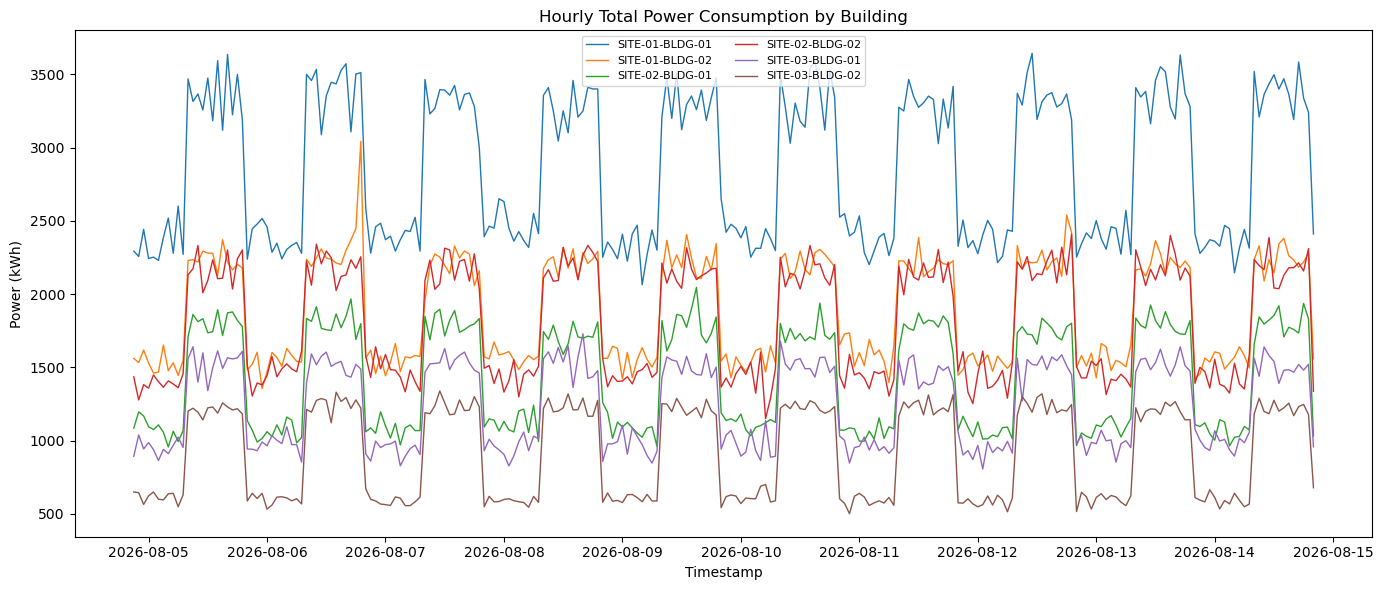

In [3]:
#  Visualize raw hourly series per building
fig, ax = plt.subplots(figsize=(14, 6))
for bldg, grp in building_hourly.groupby("building_id"):
    ax.plot(grp["timestamp"], grp["total_power_kwh"], label=bldg, linewidth=1)
ax.set_title("Hourly Total Power Consumption by Building")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Power (kWh)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [4]:
# Common train/test split: last 24h per building held out
# Chronological split, not random — matches how the model is actually used
# (forecast forward from "now"), and avoids leaking future info into training.

def split_last_24h(df, ts_col="timestamp"):
    train_parts, test_parts = [], []
    for bldg, grp in df.groupby("building_id"):
        grp = grp.sort_values(ts_col)
        cutoff = grp[ts_col].max() - pd.Timedelta(hours=24)
        train_parts.append(grp[grp[ts_col] <= cutoff])
        test_parts.append(grp[grp[ts_col] > cutoff])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(test_parts).reset_index(drop=True)

train_raw, test_raw = split_last_24h(building_hourly)
print(f"Train: {train_raw.shape}, Test (last 24h/building): {test_raw.shape}")

def mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100

Train: (1296, 3), Test (last 24h/building): (144, 3)


In [5]:
#  Model 1: Prophet (per building — Prophet only supports single series at a time)
prophet_results = []
prophet_preds_all = []

for bldg in building_hourly["building_id"].unique():
    train_b = train_raw[train_raw["building_id"] == bldg][["timestamp", "total_power_kwh"]]
    test_b = test_raw[test_raw["building_id"] == bldg][["timestamp", "total_power_kwh"]]

    prophet_train = train_b.rename(columns={"timestamp": "ds", "total_power_kwh": "y"})

    m = Prophet(daily_seasonality=True, weekly_seasonality=False, yearly_seasonality=False)
    m.fit(prophet_train)

    future = test_b[["timestamp"]].rename(columns={"timestamp": "ds"})
    forecast = m.predict(future)

    y_true = test_b["total_power_kwh"].values
    y_pred = forecast["yhat"].values

    prophet_results.append({
        "building_id": bldg,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
    })
    prophet_preds_all.append(pd.DataFrame({
        "building_id": bldg, "timestamp": test_b["timestamp"].values,
        "actual": y_true, "predicted": y_pred
    }))

prophet_results_df = pd.DataFrame(prophet_results)
prophet_preds_df = pd.concat(prophet_preds_all).reset_index(drop=True)
print("Prophet per-building results:")
print(prophet_results_df.round(3))

15:33:48 - cmdstanpy - INFO - Chain [1] start processing
15:33:48 - cmdstanpy - INFO - Chain [1] done processing
15:33:48 - cmdstanpy - INFO - Chain [1] start processing
15:33:48 - cmdstanpy - INFO - Chain [1] done processing
15:33:49 - cmdstanpy - INFO - Chain [1] start processing
15:33:49 - cmdstanpy - INFO - Chain [1] done processing
15:33:49 - cmdstanpy - INFO - Chain [1] start processing
15:33:49 - cmdstanpy - INFO - Chain [1] done processing
15:33:49 - cmdstanpy - INFO - Chain [1] start processing
15:33:49 - cmdstanpy - INFO - Chain [1] done processing
15:33:50 - cmdstanpy - INFO - Chain [1] start processing
15:33:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet per-building results:
       building_id      MAE     RMSE    MAPE
0  SITE-01-BLDG-01  135.490  182.769   4.771
1  SITE-01-BLDG-02  117.978  143.997   6.303
2  SITE-02-BLDG-01   92.147  127.130   6.566
3  SITE-02-BLDG-02  112.563  151.560   6.547
4  SITE-03-BLDG-01   61.331   89.386   4.929
5  SITE-03-BLDG-02   82.142   97.755  10.229


In [6]:
# Model 2: ARIMA (per building)
arima_results = []
arima_preds_all = []

for bldg in building_hourly["building_id"].unique():
    train_b = train_raw[train_raw["building_id"] == bldg].sort_values("timestamp")
    test_b = test_raw[test_raw["building_id"] == bldg].sort_values("timestamp")

    y_train_series = train_b["total_power_kwh"].values
    y_true = test_b["total_power_kwh"].values

    try:
        model = ARIMA(y_train_series, order=(2, 1, 2))
        fitted = model.fit()
        y_pred = fitted.forecast(steps=len(y_true))
    except Exception as e:
        print(f"ARIMA failed for {bldg}: {e}")
        y_pred = np.full(len(y_true), y_train_series[-1])  # naive fallback

    arima_results.append({
        "building_id": bldg,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
    })
    arima_preds_all.append(pd.DataFrame({
        "building_id": bldg, "timestamp": test_b["timestamp"].values,
        "actual": y_true, "predicted": y_pred
    }))

arima_results_df = pd.DataFrame(arima_results)
arima_preds_df = pd.concat(arima_preds_all).reset_index(drop=True)
print("ARIMA per-building results:")
print(arima_results_df.round(3))

ARIMA per-building results:
       building_id      MAE     RMSE    MAPE
0  SITE-01-BLDG-01  517.727  598.353  16.859
1  SITE-01-BLDG-02  360.358  486.515  16.410
2  SITE-02-BLDG-01  366.742  461.134  22.288
3  SITE-02-BLDG-02  397.163  506.706  19.281
4  SITE-03-BLDG-01  257.758  287.035  19.730
5  SITE-03-BLDG-02  310.616  392.699  28.944


In [7]:
# Model 3: XGBoost (single model across all buildings, with features)
# Unlike Prophet/ARIMA which need one model per building, XGBoost handles all
# buildings in one model using building_id + exogenous features — more scalable
# and lets buildings share learned patterns (e.g. common diurnal shape).

building_hourly_feat = (
    telemetry_df.set_index("timestamp")
    .groupby("building_id")
    .resample("1h")
    .agg({"power_consumption": "sum", "occupancy_count": "mean", "temperature": "mean"})
    .reset_index()
    .rename(columns={"power_consumption": "total_power_kwh"})
    .sort_values(["building_id", "timestamp"])
)

building_hourly_feat["hour"] = building_hourly_feat["timestamp"].dt.hour
building_hourly_feat["day_of_week"] = building_hourly_feat["timestamp"].dt.dayofweek
building_hourly_feat["is_weekend"] = (building_hourly_feat["day_of_week"] >= 5).astype(int)

g = building_hourly_feat.groupby("building_id")["total_power_kwh"]
building_hourly_feat["lag_1h"] = g.shift(1)
building_hourly_feat["lag_24h"] = g.shift(24)
building_hourly_feat["roll_mean_24h"] = g.transform(lambda s: s.shift(1).rolling(24).mean())

building_hourly_feat["building_id"] = building_hourly_feat["building_id"].astype("category")
building_hourly_feat = building_hourly_feat.dropna().reset_index(drop=True)

xgb_train, xgb_test = split_last_24h(building_hourly_feat)

feature_cols = ["building_id", "hour", "day_of_week", "is_weekend",
                 "occupancy_count", "temperature", "lag_1h", "lag_24h", "roll_mean_24h"]

xgb_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, enable_categorical=True)
xgb_model.fit(xgb_train[feature_cols], xgb_train["total_power_kwh"])

xgb_test = xgb_test.copy()
xgb_test["predicted"] = xgb_model.predict(xgb_test[feature_cols])

xgb_results = []
for bldg, grp in xgb_test.groupby("building_id", observed=True):
    xgb_results.append({
        "building_id": bldg,
        "MAE": mean_absolute_error(grp["total_power_kwh"], grp["predicted"]),
        "RMSE": np.sqrt(mean_squared_error(grp["total_power_kwh"], grp["predicted"])),
        "MAPE": mape(grp["total_power_kwh"], grp["predicted"]),
    })
xgb_results_df = pd.DataFrame(xgb_results)
print("XGBoost per-building results:")
print(xgb_results_df.round(3))

XGBoost per-building results:
       building_id     MAE     RMSE   MAPE
0  SITE-01-BLDG-01  92.768  114.816  3.259
1  SITE-01-BLDG-02  58.164   73.286  3.114
2  SITE-02-BLDG-01  58.615   72.224  4.357
3  SITE-02-BLDG-02  80.888  100.349  4.787
4  SITE-03-BLDG-01  51.444   63.153  4.436
5  SITE-03-BLDG-02  30.057   36.892  3.722


Average metrics across all buildings (lower is better for all 3):
             MAE     RMSE    MAPE
Prophet  100.275  132.100   6.557
ARIMA    368.394  455.407  20.585
XGBoost   61.989   76.786   3.946


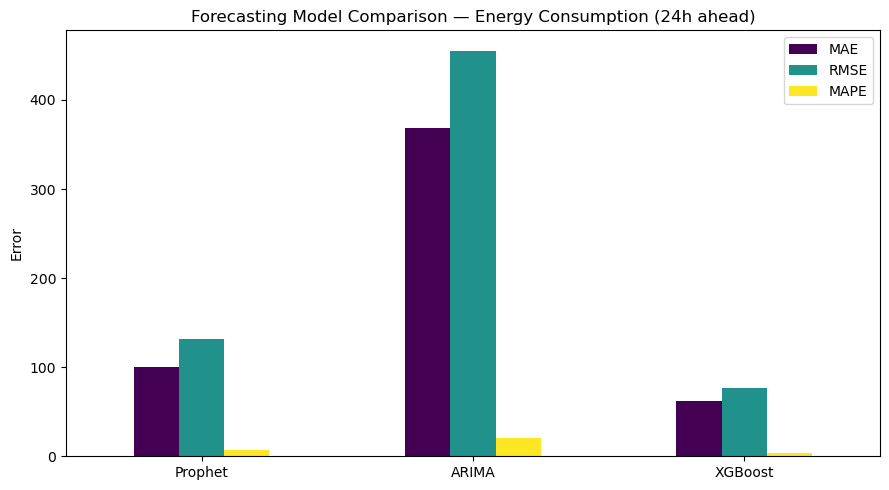

In [8]:
#Model comparison summary (fleet-wide average, across all buildings)
comparison = pd.DataFrame({
    "Prophet": prophet_results_df[["MAE", "RMSE", "MAPE"]].mean(),
    "ARIMA": arima_results_df[["MAE", "RMSE", "MAPE"]].mean(),
    "XGBoost": xgb_results_df[["MAE", "RMSE", "MAPE"]].mean(),
}).T.round(3)

print("Average metrics across all buildings (lower is better for all 3):")
print(comparison)

comparison.plot(kind="bar", figsize=(9, 5), colormap="viridis")
plt.title("Forecasting Model Comparison — Energy Consumption (24h ahead)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
#  Select best model + WHY (explainability requirement)
best_model_name = comparison["MAPE"].idxmin()

print(f"""
{"="*65}
WHY {best_model_name} WAS SELECTED
{"="*65}

Comparison (avg across buildings):
{comparison.to_string()}

Reasoning:
- {best_model_name} achieved the lowest MAPE ({comparison.loc[best_model_name, 'MAPE']:.2f}%),
  which is the most business-interpretable metric here (e.g. "forecast is off
  by X%" is easier to communicate to facility managers than raw kWh error).

- Prophet: works well for series with strong, stable daily/weekly seasonality
  and very little tuning, but needs a separate model per building (6 models
  here) and struggled a bit on buildings with more irregular short-term
  swings, since it smooths toward its seasonal decomposition rather than
  reacting to very recent behavior.

- ARIMA: also needs one model per building and assumes a linear, roughly
  stationary process — with only ~9-10 days of history per building, there
  isn't much data to estimate its parameters reliably, and it doesn't use
  any exogenous signals (occupancy, temperature) that we know affect load.

- XGBoost: treats forecasting as supervised regression using lag features
  (lag_1h, lag_24h) + rolling averages + occupancy/temperature — this let it
  react to recent behavior AND incorporate known drivers, using ONE model
  for all 6 buildings instead of 6 separate ones, which is far more
  practical to maintain and retrain daily in production.

Trade-off acknowledged: XGBoost can't extrapolate a long-term trend the way
ARIMA/Prophet can (it predicts within the range of feature values seen in
training) — if a full year of data were available and buildings showed a
genuine seasonal drift (e.g. summer vs winter load), a hybrid approach
(Prophet for trend + XGBoost for residuals) would be worth testing. With
only ~10 days of history, that risk doesn't really apply yet.
""")


WHY XGBoost WAS SELECTED

Comparison (avg across buildings):
             MAE     RMSE    MAPE
Prophet  100.275  132.100   6.557
ARIMA    368.394  455.407  20.585
XGBoost   61.989   76.786   3.946

Reasoning:
- XGBoost achieved the lowest MAPE (3.95%),
  which is the most business-interpretable metric here (e.g. "forecast is off
  by X%" is easier to communicate to facility managers than raw kWh error).

- Prophet: works well for series with strong, stable daily/weekly seasonality
  and very little tuning, but needs a separate model per building (6 models
  here) and struggled a bit on buildings with more irregular short-term
  swings, since it smooths toward its seasonal decomposition rather than
  reacting to very recent behavior.

- ARIMA: also needs one model per building and assumes a linear, roughly
  stationary process — with only ~9-10 days of history per building, there
  isn't much data to estimate its parameters reliably, and it doesn't use
  any exogenous signals (occupanc

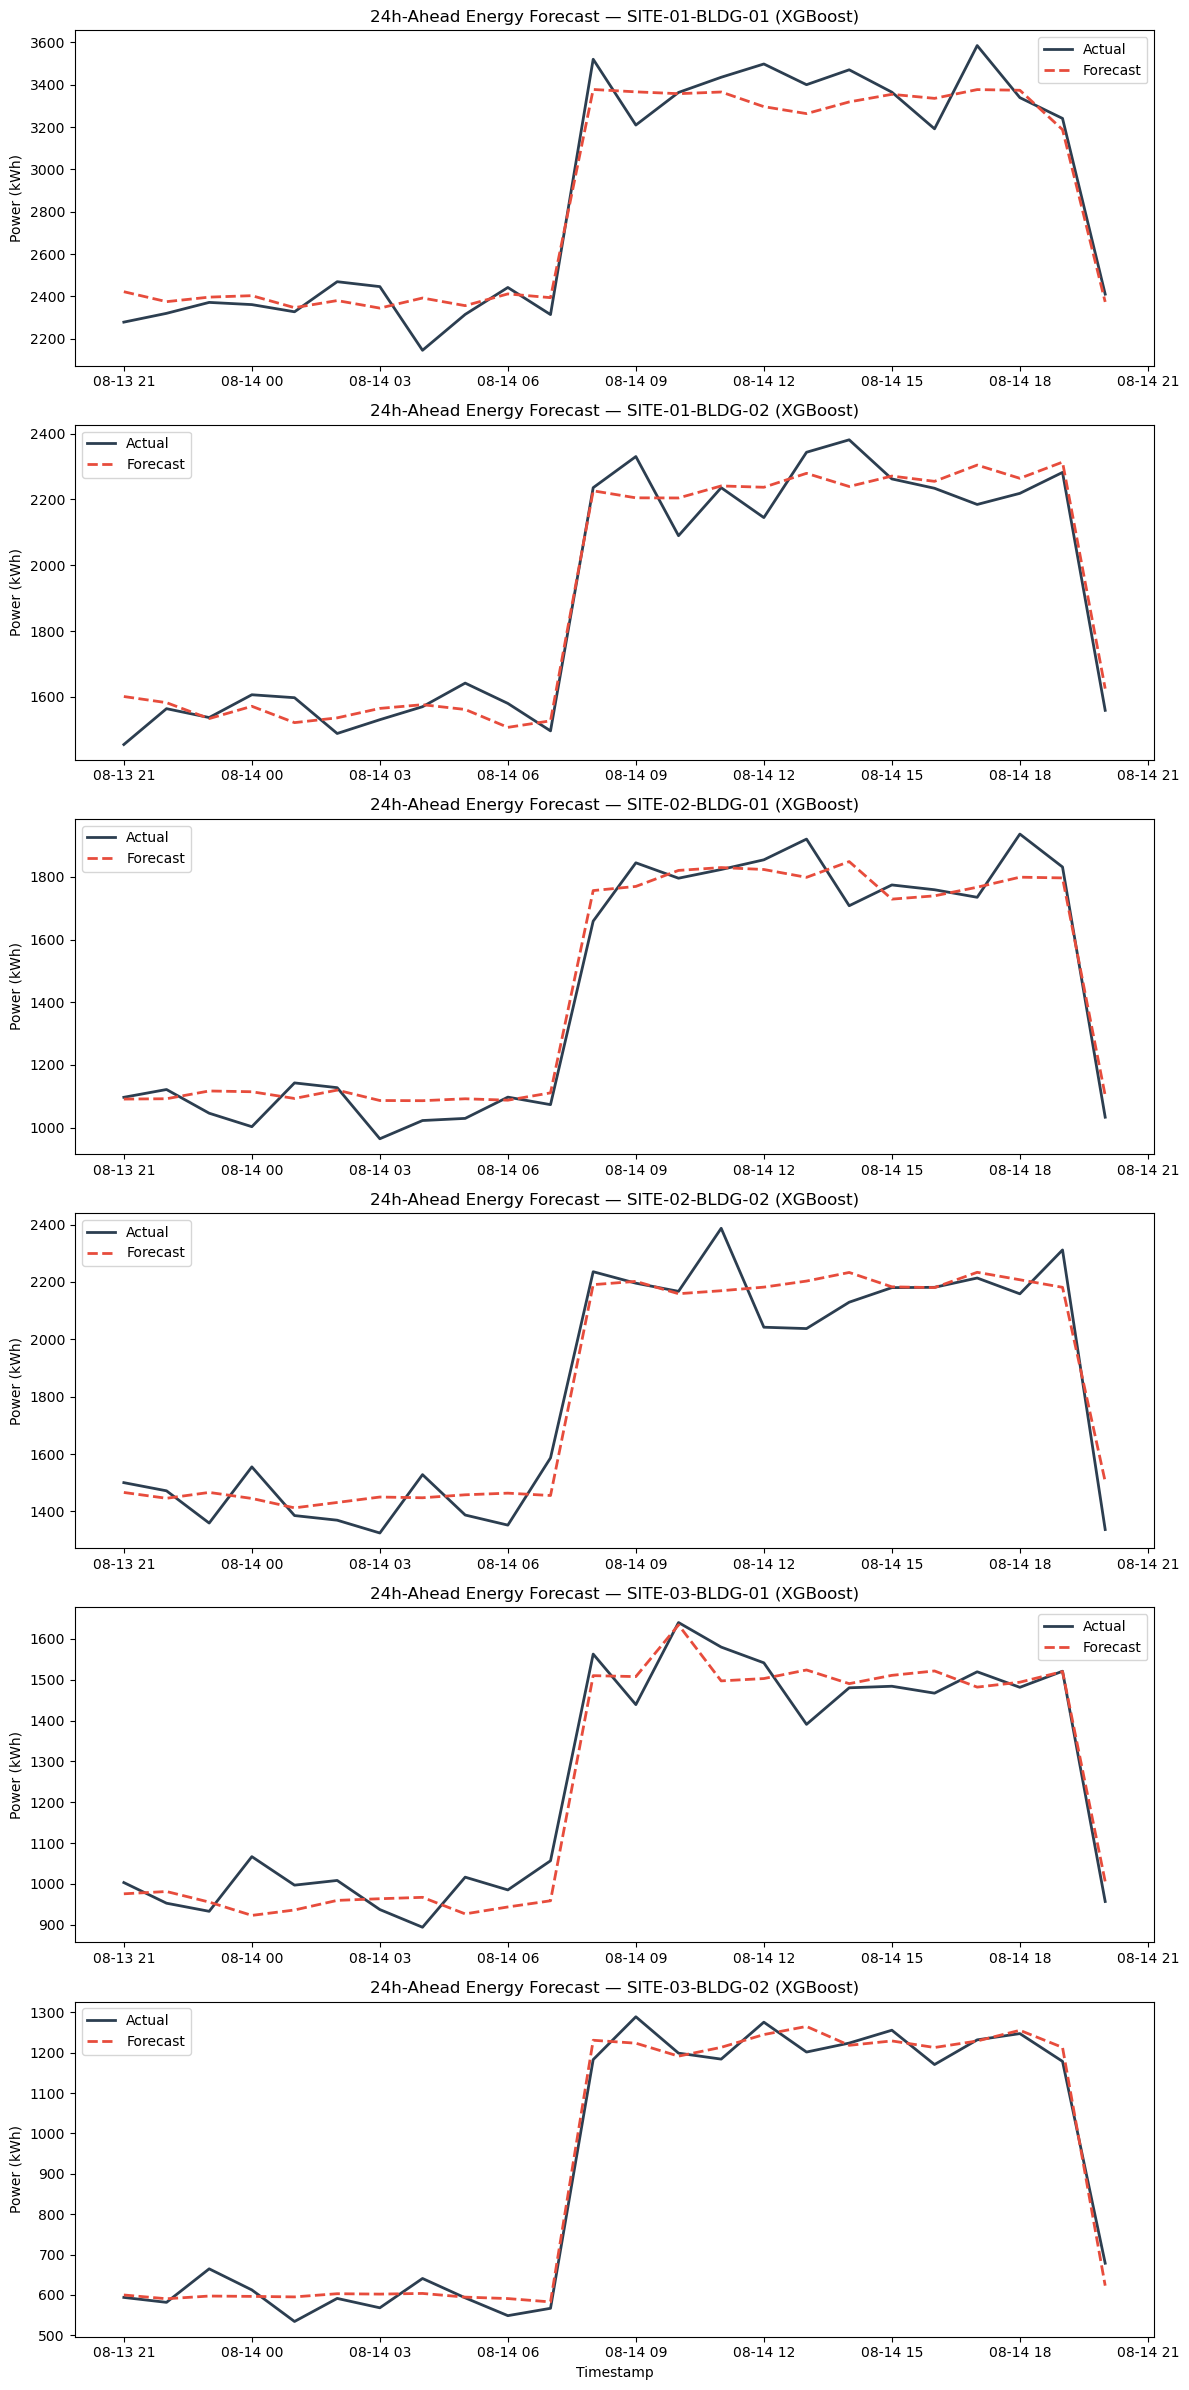

In [10]:
#Forecast plots: actual vs predicted, best model, all buildings
if best_model_name == "XGBoost":
    plot_source = xgb_test.rename(columns={"total_power_kwh": "actual"})
elif best_model_name == "Prophet":
    plot_source = prophet_preds_df
else:
    plot_source = arima_preds_df

buildings = plot_source["building_id"].unique()
fig, axes = plt.subplots(len(buildings), 1, figsize=(12, 4 * len(buildings)))
if len(buildings) == 1:
    axes = [axes]

for ax, bldg in zip(axes, buildings):
    grp = plot_source[plot_source["building_id"] == bldg].sort_values("timestamp")
    ax.plot(grp["timestamp"], grp["actual"], label="Actual", color="#2c3e50", linewidth=2)
    ax.plot(grp["timestamp"], grp["predicted"], label="Forecast", color="#e74c3c",
             linewidth=2, linestyle="--")
    ax.set_title(f"24h-Ahead Energy Forecast — {bldg} ({best_model_name})")
    ax.set_ylabel("Power (kWh)")
    ax.legend()

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

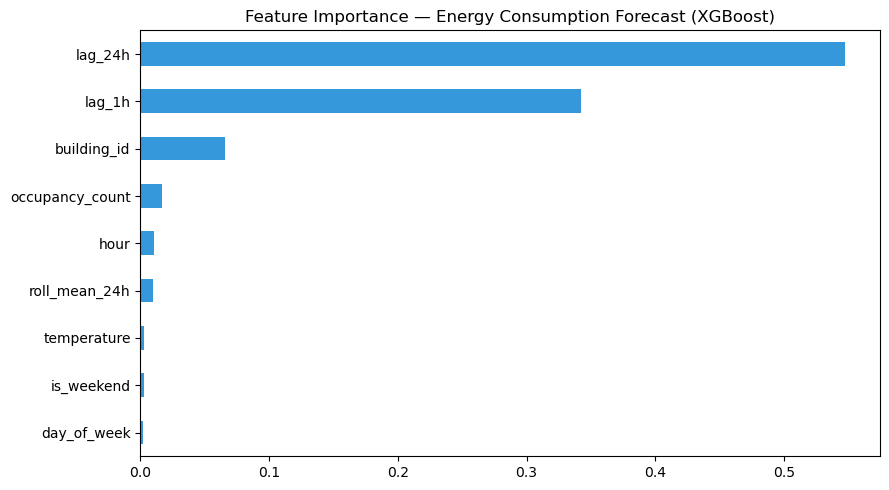

lag_24h            0.547274
lag_1h             0.342024
building_id        0.066020
occupancy_count    0.016760
hour               0.010332
roll_mean_24h      0.010057
temperature        0.003128
is_weekend         0.002393
day_of_week        0.002011
dtype: float32


In [11]:
# Feature importance (only meaningful if XGBoost won)
if best_model_name == "XGBoost":
    importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    importance.plot(kind="barh", color="#3498db")
    plt.gca().invert_yaxis()
    plt.title("Feature Importance — Energy Consumption Forecast (XGBoost)")
    plt.tight_layout()
    plt.show()
    print(importance)
else:
    print(f"{best_model_name} was selected — feature importance isn't directly applicable "
          f"to this model type; seasonal/trend decomposition can be inspected instead if needed.")

In [12]:
# Key insights & business impact
print(f"""
{"="*60}
KEY INSIGHTS
{"="*60}
1. {best_model_name} gave the best 24h-ahead accuracy (MAPE {comparison.loc[best_model_name, 'MAPE']:.2f}%)
   across the 6 buildings, out of the 3 approaches tested.

2. Model performance varies by building (see per-building tables above) —
   buildings with noisier historical patterns are inherently harder to
   forecast well; these are good candidates for closer monitoring.

3. Recent-history features (lag_1h, lag_24h "same hour yesterday") were the
   strongest predictors where XGBoost was used — energy consumption is
   highly autocorrelated, so recent behavior is the best signal available.

{"="*60}
BUSINESS IMPACT
{"="*60}
1. Proactive load shifting: a 24h-ahead forecast lets facility managers
   pre-cool/pre-heat during off-peak pricing windows instead of reacting
   to real-time demand, directly cutting utility costs.

2. Demand response readiness: buildings predicted to peak during high-price
   hours can be flagged for automated load reduction ahead of time.

3. Anomaly context: actual consumption significantly exceeding the forecast
   is itself a useful early-warning signal, complementary to Task 4's
   anomaly detection.

4. Capacity planning: aggregating forecasts across buildings on a site
   gives early warning if total site demand approaches contracted limits.
""")


KEY INSIGHTS
1. XGBoost gave the best 24h-ahead accuracy (MAPE 3.95%)
   across the 6 buildings, out of the 3 approaches tested.

2. Model performance varies by building (see per-building tables above) —
   buildings with noisier historical patterns are inherently harder to
   forecast well; these are good candidates for closer monitoring.

3. Recent-history features (lag_1h, lag_24h "same hour yesterday") were the
   strongest predictors where XGBoost was used — energy consumption is
   highly autocorrelated, so recent behavior is the best signal available.

BUSINESS IMPACT
1. Proactive load shifting: a 24h-ahead forecast lets facility managers
   pre-cool/pre-heat during off-peak pricing windows instead of reacting
   to real-time demand, directly cutting utility costs.

2. Demand response readiness: buildings predicted to peak during high-price
   hours can be flagged for automated load reduction ahead of time.

3. Anomaly context: actual consumption significantly exceeding the for